# Ideal NMPC on the PrOMMiS mixer-settler

Rare earth elements are recovered from an acidic leach solution by
liquid-liquid extraction: the aqueous leachate is contacted with an
organic solvent, kerosene carrying the extractant DEHPA, which pulls the
rare earth ions across the phase boundary and leaves the impurities
behind. The model is the mixer-settler solvent extraction unit from
[PrOMMiS](https://github.com/prommis/prommis), built on IDAES, taken as
PrOMMiS wrote it: one extraction stage, with the feed composition of a
coal-refuse leachate carrying nine rare earths (Sc, Y, La, Ce, Pr, Nd,
Sm, Gd, Dy) at milligram-per-liter levels under percent-level Al, Ca,
and Fe impurities in sulfuric acid.

## The process

One stage is three vessels. The two phases meet only in the mixer, a
stirred tank both phases share; the settlers downstream are single-phase
plug-flow tanks that model the disengagement lag between the mixer and
the outlets.

```
                    +--------------+
 aqueous feed ----->|              |--aq-->[ aqueous settler ]--> raffinate
 (leachate)         |    mixer     |
 organic feed ----->|  (2 phases)  |--org->[ organic settler ]--> loaded solvent
 (kerosene+DEHPA)   |              |
                    +--------------+
```

In the mixer the metals distribute between the phases through the DEHPA
complexation equilibria, metal ions trading places with protons, so
extraction pushes acid back into the aqueous phase. The aqueous effluent
(the raffinate) carries what was not extracted out through one settler;
the organic effluent (the loaded solvent) carries the rare earth
complexes out through the other. In a multi-stage train the organic
stream runs backward through the stage sequence, making the train
counter-current; this example runs one stage.

## The dynamics

The states are inventories. With $n_j$ the molar holdup of species $j$
in the mixer, $V$ the mixer volume, $\varphi$ the aqueous volume
fraction, and $c_j$ the phase concentration, every mixer balance has the
same shape, indexed over the species of its phase:

$$\frac{dn_j}{dt} = F_{in}\, c_{j}^{feed} - F\, c_j
+ \sum_r \nu_{jr}\,\xi_r ,
\qquad n_j = V \varphi\, c_j ,$$

with $F$ the phase volumetric flow, $\nu_{jr}$ the stoichiometry, and
$\xi_r$ the extent of reaction $r$: the metal transfer complexations
and, in the aqueous phase, the bisulfate dissociation. The settlers are
the same balance distributed along the vessel, holdup per unit length
$\tilde n_j = A\, c_j$ at normalized position $x$:

$$L\,\frac{\partial \tilde n_j}{\partial t} =
-\frac{\partial (F c_j)}{\partial x} ,$$

one equation per species per position, transport only.

Not every inventory is a state. The transfer reactions are equilibria,
not rate laws, so the extents $\xi_r$ are algebraic and the organic
metal inventories follow the aqueous side instantaneously. The solvents
close by density ($c_{H2O} = \rho^{aq} - \sum_j c_j$ in the aqueous
phase, kerosene likewise in the organic), so their holdups carry no
independent memory of their own: in the settlers, where the vessel runs
full at fixed volume, the solvent inventory is pinned outright; in the
mixer the water holdup moves only with the phase split $\varphi$, and
it is exactly the inventory that remembers the split. Bisulfate rides
its dissociation equilibrium. What remains is the memory the loop feeds
back:

- the mixer's aqueous holdups, every species but bisulfate (the water
  member carrying the phase split),
- the mixer's free extractant holdup (DEHPA), the one organic inventory
  with memory of its own,
- the settlers' species holdups at each interior position, water,
  bisulfate, and kerosene excluded.

Everything else, concentrations, flows, the phase split, the extents,
is algebra the solver reconstructs at each instant.

## The declared model

[`models/prommis_sx.py`](models/prommis_sx.py) builds the stage and
declares the states above, both feed flows as the manipulated inputs
(with their operating limits as bounds), and additive zero-mean noise
in every state's balance as the declared disturbances. The plant has two
timescales: the mixer holds 0.4 cubic meters against 124 cubic meters
per hour of combined feed, twelve seconds of hydraulic residence, but
the metal inventories relax over tens of minutes, because the organic
phase carries the metals at fifty to a hundred times the aqueous
concentration and the equilibrium buffers any excess. The loop samples
the inventories it controls: fifteen-minute steps. The
setpoint is the steady
operating point: the drto steady branch does not yet reduce spatially
distributed models, so the targets come from PrOMMiS's own steady
flowsheet, solved at the same dosage and read back through the dynamic
model's holdup equations.

In [1]:
import time

import pyomo.environ as pyo

import drto
from models.prommis_sx import build, noise_sigmas, steady_targets

m = build(N=8, h=0.25)
steady_targets(m)
drto.info(m)

2026-08-03 22:16:16 [INFO] idaes.init.fs.mixer_settler_ex.mixer[1].unit.mscontactor: Stream Initialization Completed.


2026-08-03 22:16:16 [INFO] idaes.init.fs.mixer_settler_ex.mixer[1].unit.mscontactor: Initialization Completed, optimal - <undefined>


Ipopt 3.13.2: linear_solver="ma57"
max_iter=200
nlp_scaling_method="gradient-based"
tol=1e-06


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collect

horizon,"fs._time (ContinuousSet, 25 points)"
states,"fs.ms.mixer[1].unit.mscontactor.aqueous_material_holdup_1_liquid_H2O (free, mol), fs.ms.mixer[1].unit.mscontactor.aqueous_material_holdup_1_liquid_H (free, mol), fs.ms.mixer[1].unit.mscontactor.aqueous_material_holdup_1_liquid_SO4 (free, mol), fs.ms.mixer[1].unit.mscontactor.aqueous_material_holdup_1_liquid_Cl (free, mol), fs.ms.mixer[1].unit.mscontactor.aqueous_material_holdup_1_liquid_Sc (free, mol), fs.ms.mixer[1].unit.mscontactor.aqueous_material_holdup_1_liquid_Y (free, mol), fs.ms.mixer[1].unit.mscontactor.aqueous_material_holdup_1_liquid_La (free, mol), fs.ms.mixer[1].unit.mscontactor.aqueous_material_holdup_1_liquid_Ce (free, mol), fs.ms.mixer[1].unit.mscontactor.aqueous_material_holdup_1_liquid_Pr (free, mol), fs.ms.mixer[1].unit.mscontactor.aqueous_material_holdup_1_liquid_Nd (free, mol), fs.ms.mixer[1].unit.mscontactor.aqueous_material_holdup_1_liquid_Sm (free, mol), fs.ms.mixer[1].unit.mscontactor.aqueous_material_holdup_1_liquid_Gd (free, mol), fs.ms.mixer[1].unit.mscontactor.aqueous_material_holdup_1_liquid_Dy (free, mol), fs.ms.mixer[1].unit.mscontactor.aqueous_material_holdup_1_liquid_Al (free, mol), fs.ms.mixer[1].unit.mscontactor.aqueous_material_holdup_1_liquid_Ca (free, mol), fs.ms.mixer[1].unit.mscontactor.aqueous_material_holdup_1_liquid_Fe (free, mol), fs.ms.mixer[1].unit.mscontactor.organic_material_holdup_1_organic_DEHPA (free, mol), fs.ms.aqueous_settler[1].unit.material_holdup_1_0_liquid_H (free, mol/m), fs.ms.aqueous_settler[1].unit.material_holdup_1_0_liquid_SO4 (free, mol/m), fs.ms.aqueous_settler[1].unit.material_holdup_1_0_liquid_Cl (free, mol/m), fs.ms.aqueous_settler[1].unit.material_holdup_1_0_liquid_Sc (free, mol/m), fs.ms.aqueous_settler[1].unit.material_holdup_1_0_liquid_Y (free, mol/m), fs.ms.aqueous_settler[1].unit.material_holdup_1_0_liquid_La (free, mol/m), fs.ms.aqueous_settler[1].unit.material_holdup_1_0_liquid_Ce (free, mol/m), fs.ms.aqueous_settler[1].unit.material_holdup_1_0_liquid_Pr (free, mol/m), fs.ms.aqueous_settler[1].unit.material_holdup_1_0_liquid_Nd (free, mol/m), fs.ms.aqueous_settler[1].unit.material_holdup_1_0_liquid_Sm (free, mol/m), fs.ms.aqueous_settler[1].unit.material_holdup_1_0_liquid_Gd (free, mol/m), fs.ms.aqueous_settler[1].unit.material_holdup_1_0_liquid_Dy (free, mol/m), fs.ms.aqueous_settler[1].unit.material_holdup_1_0_liquid_Al (free, mol/m), fs.ms.aqueous_settler[1].unit.material_holdup_1_0_liquid_Ca (free, mol/m), fs.ms.aqueous_settler[1].unit.material_holdup_1_0_liquid_Fe (free, mol/m), fs.ms.organic_settler[1].unit.material_holdup_1_0_organic_DEHPA (free, mol/m), fs.ms.organic_settler[1].unit.material_holdup_1_0_organic_Al_o (free, mol/m), fs.ms.organic_settler[1].unit.material_holdup_1_0_organic_Ca_o (free, mol/m), fs.ms.organic_settler[1].unit.material_holdup_1_0_organic_Fe_o (free, mol/m), fs.ms.organic_settler[1].unit.material_holdup_1_0_organic_Sc_o (free, mol/m), fs.ms.organic_settler[1].unit.material_holdup_1_0_organic_Y_o (free, mol/m), fs.ms.organic_settler[1].unit.material_holdup_1_0_organic_La_o (free, mol/m), fs.ms.organic_settler[1].unit.material_holdup_1_0_organic_Ce_o (free, mol/m), fs.ms.organic_settler[1].unit.material_holdup_1_0_organic_Pr_o (free, mol/m), fs.ms.organic_settler[1].unit.material_holdup_1_0_organic_Nd_o (free, mol/m), fs.ms.organic_settler[1].unit.material_holdup_1_0_organic_Sm_o (free, mol/m), fs.ms.organic_settler[1].unit.material_holdup_1_0_organic_Gd_o (free, mol/m), fs.ms.organic_settler[1].unit.material_holdup_1_0_organic_Dy_o (free, mol/m)"
dynamics,"fs.ms.mixer[j].unit.mscontactor.aqueous_material_accumulation[k,j,liquid,i] == 1e-06*(kg/mg)*(fs.ms.mixer[j].unit.mscontactor.aqueous_inlet_state[k].flow_vol*fs.ms.mixer[j].unit.mscontactor.aqueous_inlet_state[k].conc_mass_comp[i]/fs.leach_soln.mw[i]) - 1e-06*(kg/mg)*(fs.ms.mixer[j].unit.mscontactor.aqueous[k,j].flow_vol*fs.ms.mixer[j].unit.mscontactor.aqueous[k,j].conc_mass_comp[i]/fs.leach_soln.mw[i]) + fs.ms.mi

## The loop, one call

An off-spec start: the mixer holds half again the rare earth
inventory of the operating point, an upstream upset that just cleared.
Eight samples of closed loop drive the inventories back: at each step
the controller solves at the measured state, the first solvent move is
implemented on the one-sample plant, and the simulated state feeds
back as the next measurement.

In [2]:
for j in ("Sc", "Y", "La", "Ce", "Pr", "Nd", "Sm", "Gd", "Dy"):
    m.ic_maq[j] = 1.5 * pyo.value(m.ic_maq[j])

tic = time.time()
history = drto.ideal_nmpc(m, steps=8, solver="ipopt")
print(history)
print(f"{time.time() - tic:.0f} s for 8 steps, a controller and a plant solve each")

drto nmpc history: 8 steps, states aqueous_material_holdup_1_liquid_H2O, aqueous_material_holdup_1_liquid_H, aqueous_material_holdup_1_liquid_SO4, aqueous_material_holdup_1_liquid_Cl, aqueous_material_holdup_1_liquid_Sc, aqueous_material_holdup_1_liquid_Y, aqueous_material_holdup_1_liquid_La, aqueous_material_holdup_1_liquid_Ce, aqueous_material_holdup_1_liquid_Pr, aqueous_material_holdup_1_liquid_Nd, aqueous_material_holdup_1_liquid_Sm, aqueous_material_holdup_1_liquid_Gd, aqueous_material_holdup_1_liquid_Dy, aqueous_material_holdup_1_liquid_Al, aqueous_material_holdup_1_liquid_Ca, aqueous_material_holdup_1_liquid_Fe, organic_material_holdup_1_organic_DEHPA, material_holdup_1_0_liquid_H, material_holdup_1_0_liquid_SO4, material_holdup_1_0_liquid_Cl, material_holdup_1_0_liquid_Sc, material_holdup_1_0_liquid_Y, material_holdup_1_0_liquid_La, material_holdup_1_0_liquid_Ce, material_holdup_1_0_liquid_Pr, material_holdup_1_0_liquid_Nd, material_holdup_1_0_liquid_Sm, material_holdup_1_0_liq

## The actual trajectories

The rare earth inventories walk back onto their targets while the
solvent flow does the work, rising to strip the excess and settling
back to its operating point.

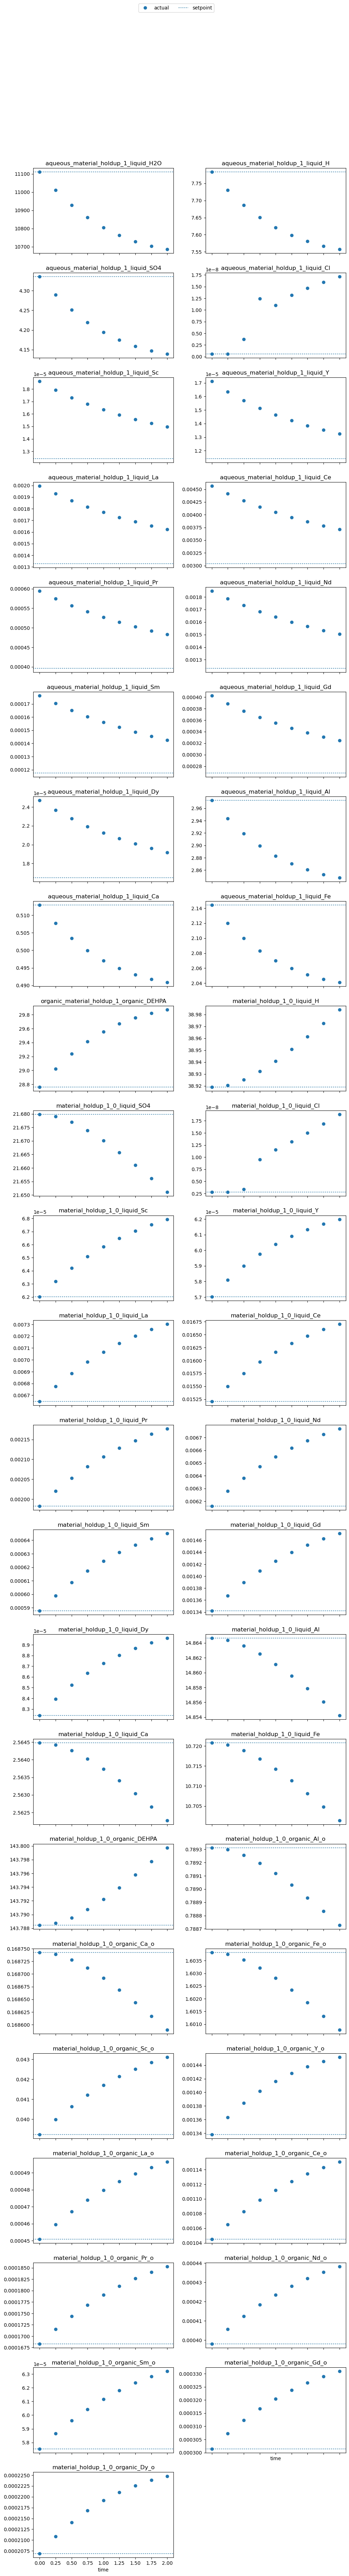

In [3]:
axes = drto.plot_states(history)

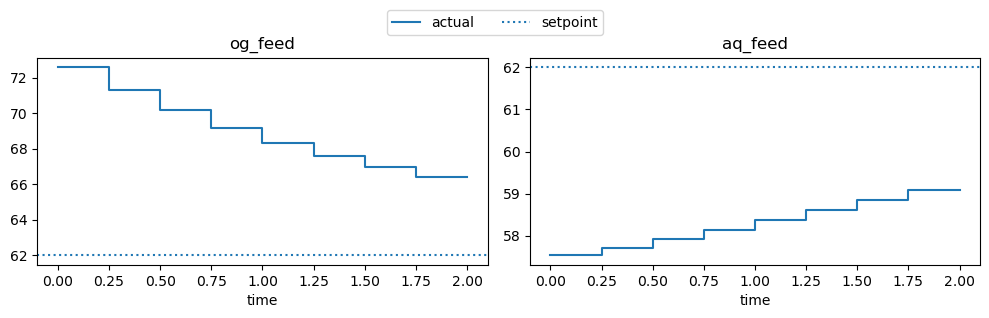

In [4]:
axes = drto.plot_controls(history)

## The same loop under process noise

The same loop from the operating point, with seeded zero-mean draws in
the nine rare earth inventory balances, a third of each steady
inventory per hour at one sigma: the grade of the incoming leachate
wandering. The controller holds every inventory
in a band around its target with both feeds working.


2026-08-03 22:17:11 [INFO] idaes.init.fs.mixer_settler_ex.mixer[1].unit.mscontactor: Stream Initialization Completed.


2026-08-03 22:17:11 [INFO] idaes.init.fs.mixer_settler_ex.mixer[1].unit.mscontactor: Initialization Completed, optimal - <undefined>


Ipopt 3.13.2: linear_solver="ma57"
max_iter=200
nlp_scaling_method="gradient-based"
tol=1e-06


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collect

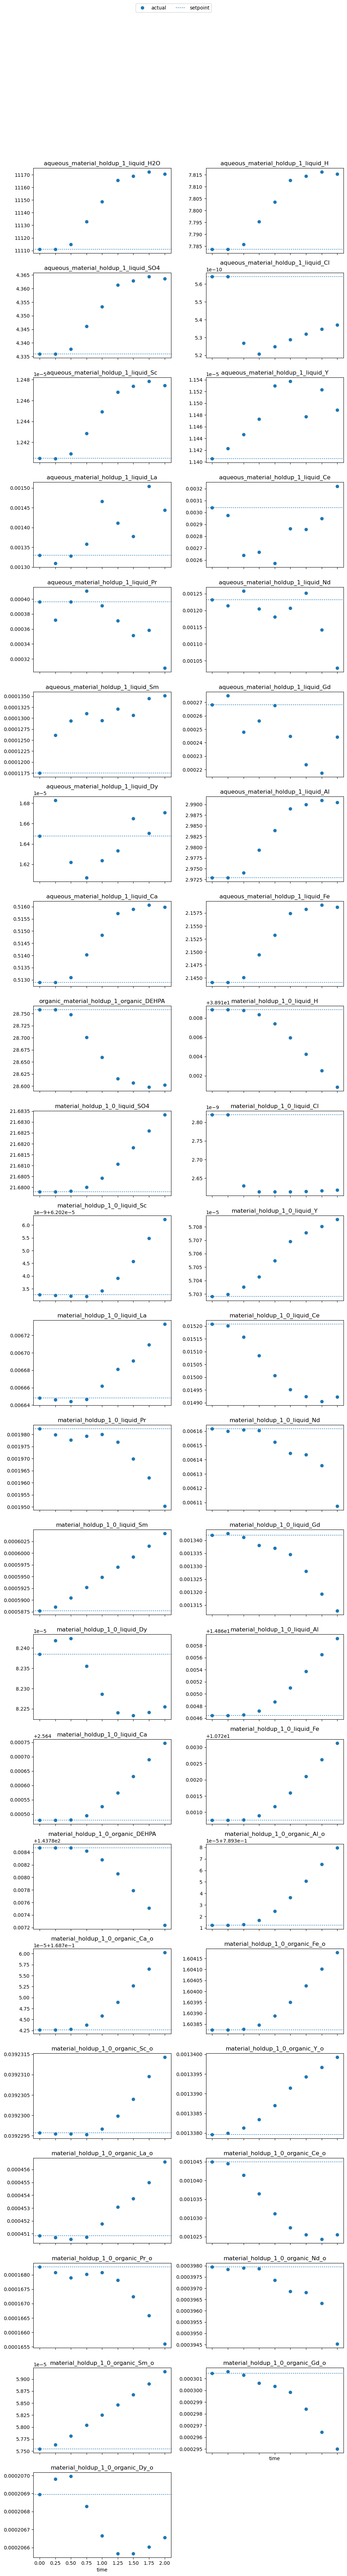

In [5]:
m2 = build(N=8, h=0.25)
steady_targets(m2)
noisy = drto.ideal_nmpc(m2, steps=8, solver="ipopt",
                        disturbances=noise_sigmas(m2), seed=7)
axes = drto.plot_states(noisy)

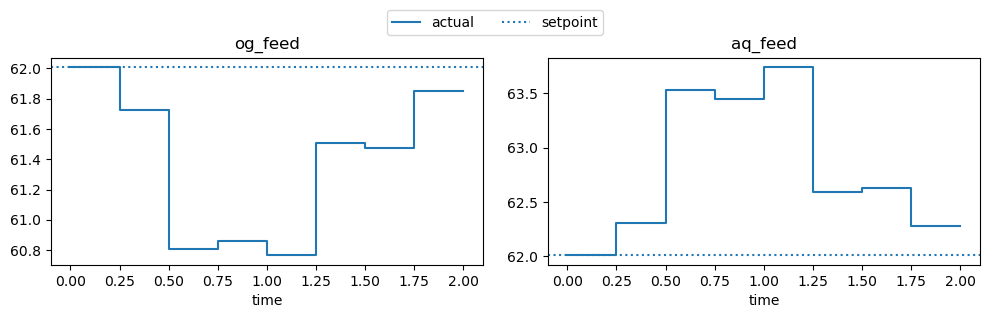

In [6]:
axes = drto.plot_controls(noisy)